In [40]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Reading the dataset and conducting preprocessing (if necessary)

In [41]:
df= pd.read_csv('/Users/adityamaheshnagare/Downloads/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv')

In [42]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [43]:
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

In [44]:
df.shape

(2000, 12)

In [45]:
# To check for missing values in the dataset
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [46]:
#Checking for duplicate rows
df.duplicated().sum()

np.int64(0)

All the cells seem to have values and there are no missing values. There are no duplicate entries as well.

### Describing the dataset

This is done to get a hold of the basic statistics that represent the given dataset.
For my ease of readability and understanding, I have described the features in two parts: 
- 1. Learner Outcome Metrics
- 2. Engagement and feedback metrics 

In [47]:
# Descriptive statistics for Learner outcome metrics
df[['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',]].describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883
std,0.159667,5.716641,10.695618,0.162747
min,0.300000,6.159240,40.386725,0.020000
25%,0.489260,23.124673,70.897590,0.280035
50%,0.603091,26.938629,78.020567,0.394820
75%,0.712797,30.885600,85.444286,0.511432
max,0.980000,40.000000,100.000000,0.700000


In [48]:
print(f" Median of Completion Rate: {df['completion_rate'].median()}")
print(f" Median of Average Score Improvement: {df['avg_score_improvement'].median()}")
print(f" Median of Average Quiz Score: {df['avg_quiz_score'].median()}")
print(f" Median of Dropout Rate: {df['dropout_rate'].median()}")

 Median of Completion Rate: 0.6030908576
 Median of Average Score Improvement: 26.938628950000002
 Median of Average Quiz Score: 78.020566685
 Median of Dropout Rate: 0.39482041775


The median values of above metrics are very similar to their respective mean values. This indicates that the data distribution might be symmetric (*not necessarily* Gaussian in nature though). We shall study more about the distributions in the upcoming Univariate EDA section.

In [49]:
# Descriptive statistics for Learner engagement and feedback metrics
df[['avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate' ]].describe()

,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.894242,0.856458,0.319204,4.503437,0.845876
max,1.000000,1.000000,0.641111,5.000000,1.000000


In [50]:
print(f" Median of Average Watch Time: {df['avg_watch_time'].median()}")
print(f" Median of Assignment Submission Rate: {df['assignment_submission_rate'].median()}")
print(f" Median of Forum Activity Rate: {df['forum_activity_rate'].median()}")
print(f" Median of Average Feedback Score: {df['avg_feedback_score'].median()}")
print(f" Median of Feedback Response Rate: {df['feedback_response_rate'].median()}")

 Median of Average Watch Time: 0.78033006855
 Median of Assignment Submission Rate: 0.75638041845
 Median of Forum Activity Rate: 0.24977069515
 Median of Average Feedback Score: 4.205988776
 Median of Feedback Response Rate: 0.73721277875


Similarly, the median values of Engagement and Feedback metrics are similar to their respective mean values. This too suggets that their data distribution might be symmetric as well.

Inferencing from the overall descriptive statistics of the metrics, we can use this knowledge to leverage the process of defining instructor effectivess and its score by defining inclusion or exclusion of metrics, choice of central tendency to be used, defining consistency of the individual features/metrics. This will significantly help in model building.

### EDA- Univariate Analysis:

Here, I will be plotting data distribution plots (histograms) to study and infer more about data qualities for some features.

Text(0, 0.5, 'Frequency')

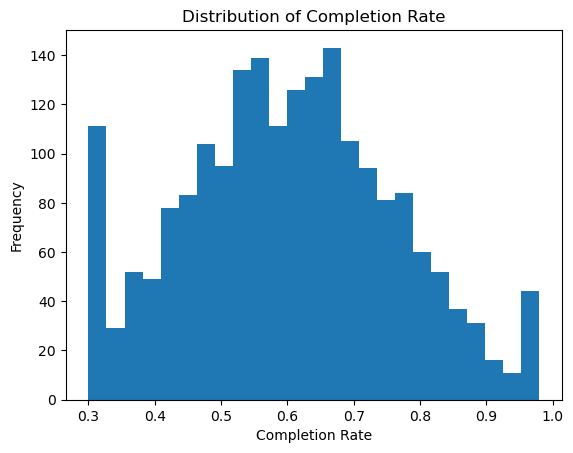

In [51]:
# data distribution of completion rate
plt.figure(1)
plt.hist(df['completion_rate'], bins=25)
plt.title('Distribution of Completion Rate')
plt.xlabel('Completion Rate')
plt.ylabel('Frequency')


Inference: Above completion rate distribution suggests that the distribution follows a bimodal distribution suggesting that most batches have a completion rate of around 0.55 to 0.67 (55-67 %). A significant number of batches have completeion rates around 30% and 95-97% as well, concentrated at the either end of the distribution

This distribution suggests substantial variation of completion rate across batches. We may infer some underlying factors like instructor effectiveness, course characteristics, or learner-related differences; influence completion. This can be studied with further bivariate/multi-variate analysis.

Text(0, 0.5, 'Frequency')

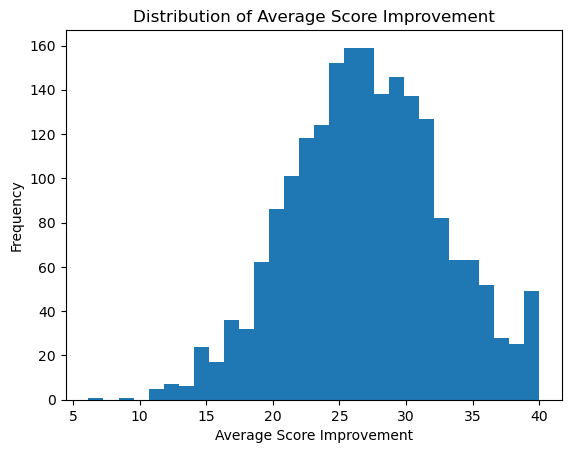

In [52]:
# Data Distribution for Average Score Improvement
plt.hist(df['avg_score_improvement'], bins=30)
plt.title('Distribution of Average Score Improvement')
plt.xlabel('Average Score Improvement')
plt.ylabel('Frequency')

Inference: The distribution of average score improvement is approximately normal, with most batches clustered around the mean improvement score (approximately 27). This indicates that learner improvement is relatively consistent across most batches, with with batches exhibiting exceptionally high improvements and only a few batches showing low improvements.

Text(0, 0.5, 'Frequency')

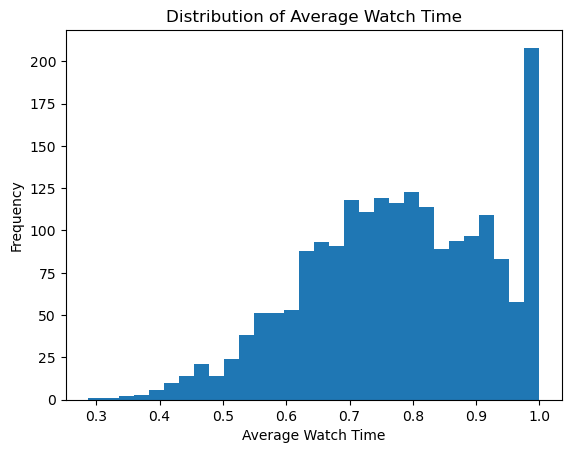

In [53]:
# Data Distribution for Average Watch Time
plt.hist(df['avg_watch_time'], bins=30)
plt.title('Distribution of Average Watch Time')
plt.xlabel('Average Watch Time')
plt.ylabel('Frequency')

Inference: The distribution of average aatch aime seems to be left-skewed, with a large concentration of batches having normalized watch times close to 1.0. This suggests that learners in many batches watch most of the course video content, while comparatively fewer batches exhibit lower levels of engagement.

Since learner engagement is an important aspect of the learning experience, average watch time may serve as a useful indicator of instructor effectiveness when analysed alongside learning outcomes such as completion rate and score improvement.

Text(0, 0.5, 'Frequency')

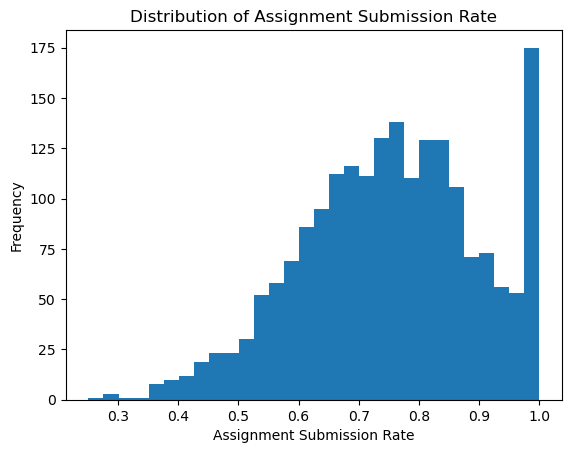

In [54]:
# Data Distribution for Assignment Submission Rate
plt.hist(df['assignment_submission_rate'], bins=30)
plt.title('Distribution of Assignment Submission Rate')
plt.xlabel('Assignment Submission Rate')
plt.ylabel('Frequency')

Inference: It has a similar distribution to that of average watch time. We shall investigate their correlation later to determine whether they dependent and hence redundant, or actually independent and individually important.

Text(0, 0.5, 'Frequency')

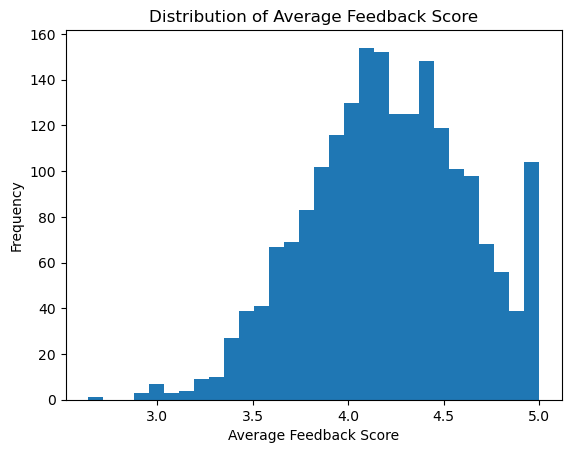

In [55]:
plt.hist(df['avg_feedback_score'], bins=30)
plt.title('Distribution of Average Feedback Score')
plt.xlabel('Average Feedback Score')
plt.ylabel('Frequency')

Inference: Above plot suggests a fairly bimodal distribution of ratings at around 4 - 4.5, along with some considerable major rating numbers at  around 5.

In [56]:
# It is important to understand the distribution of courses to individual instructors. 

counts= df['instructor_id'].value_counts()
print(f"Number of unique instructors: {len(counts)}")
print(f"Maximum number of courses taught by an instructor: {counts.max()}")
print(f"Minimum number of courses taught by an instructor: {counts.min()}")
print(f"Top 10 instructors with most courses: {counts.head(10)}")
print(f"Bottom 10 instructors with least courses: {counts.tail(10)}")
print(f"Instructors with more than 10 courses: {len(counts[counts>10])}")
print(f"Instructors with more than 20 courses: {len(counts[counts>20])}")


Number of unique instructors: 120
Maximum number of courses taught by an instructor: 31
Minimum number of courses taught by an instructor: 7
Top 10 instructors with most courses: instructor_id
I_062    31
I_101    27
I_099    26
I_033    26
I_092    26
I_113    26
I_051    26
I_090    26
I_001    25
I_017    24
Name: count, dtype: int64
Bottom 10 instructors with least courses: instructor_id
I_043    10
I_080    10
I_083    10
I_068    10
I_079     9
I_041     8
I_091     8
I_077     8
I_031     8
I_102     7
Name: count, dtype: int64
Instructors with more than 10 courses: 109
Instructors with more than 20 courses: 19


In [57]:
df['instructor_id'].nunique()

120

In [58]:
# To find the number of unique courses in the dataset
df['course_id'].nunique()

25

### EDA- Bivariate Analysis

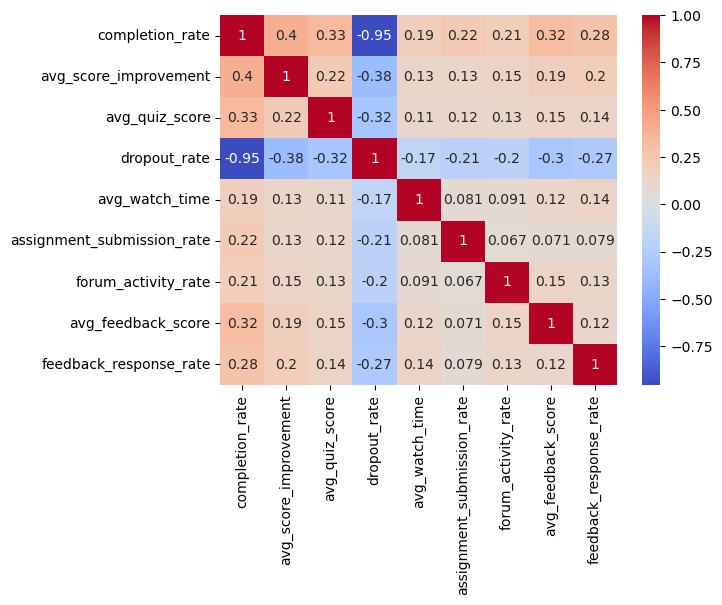

In [59]:
#Plotting Correlation heatmap to understand correlation between different metrics.
corr= df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


**Inferences from Above Heatmap (Correlation): **
- Completion rate and drop out rate are highly negatively correlated (-0.95), it suggests that most students who do not complete the course, *may* drop out. However, not completing the course is not a causation of students dropping out, rather just one of the plausible reasons. There would be other reasons as to why students may drop a course. Nonetheless, for further instructor-level analysis, it may be safe to drop the drop out feature.

-  Dropout rate is slightly negatively correlated (-0.4 to -0.3) to average quiz score and average quiz score improvements, indicating that the loss of learning imapcted their scores due to dropping out of it (if they were allowed to and have taken the quiz regardless) or that they may have missed the quiz due to them dropping the course. Again, not a causation.

- Completion Rate is quite positively correlated to average score improvement (0.4) and slightly positively correlated (~ 0.25 to 0.35) to average quiz score, average feedback score and feedback response rate, suggesting that completing a course may have positive imapct on quiz scores and score improvements while students may provide feedbacks on the course material or instructor (positive or negative feedbacks) after completing the entire course and judging according to their understanding. These are some possible reasons that I can hypothesise.

- Another interesting inference is that though average watch time and assignment submission rate follow similar distributions, their correlation is significantly negligible....this may suggest the presence of ceiling effect. Although average watch time and assignment submission rate exhibit similar distributions, their correlation coefficient (0.081) indicates that they capture different aspects of learner engagement. Consequently, both features are retained for further analysis, as they may provide complementary information about instructor effectiveness.

Text(0, 0.5, 'Completion Rate')

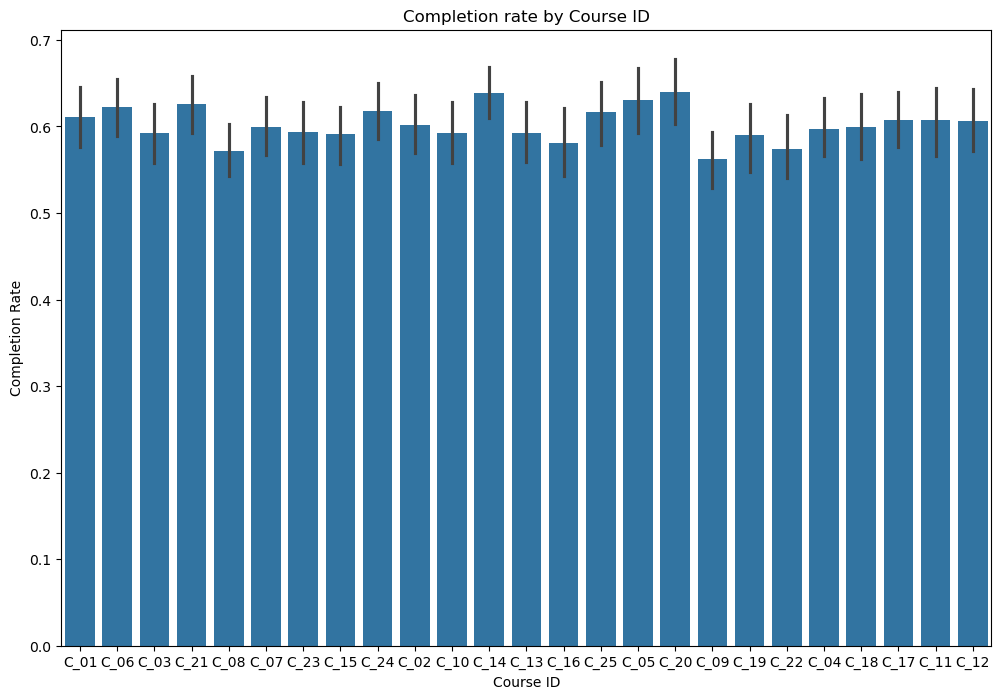

In [60]:
# Plotting the completion rate by course ID to understand the distribution of completion rates across different courses.
plt.figure(figsize=(12, 8))
sns.barplot(x='course_id', y='completion_rate', data=df)
plt.title('Completion rate by Course ID')
plt.xlabel('Course ID')
plt.ylabel('Completion Rate')

**Inference from above visualisation:**

Above barplot visualisation explains completion rate by course id. It suggests that there is not much variability in completion rates across courses and all courses have a completion rate of more than 50%. This can suggest that the courses themselves might be of similar difficulty level and of moderate level at that. However, this visualisation alone does not allow us to determine the impact of individual instructors, as each course may be taught by multiple instructors across different batches.

When considered alongside the completion rate distribution, which exhibits substantial batch-to-batch variability, it appears that factors beyond the course itself contribute to learner completion. These factors may include instructor effectiveness, learner characteristics, or other batch-specific influences.


### Intructor-level Analysis

Considering all of the above observations and visual implications, I have decided to move further to construct a pivot table, centered around instructor ids to focus on Instructot-Level Analysis.

This table shall be used as the primary data source for our model building later.

In [61]:
# Pivot table for instructor-level info
df_pivot = df.pivot_table(
    index='instructor_id',
    values=[
        'completion_rate',
        'avg_score_improvement',
        'avg_watch_time',
        'assignment_submission_rate',
        'forum_activity_rate',
        'avg_feedback_score',
        'feedback_response_rate'
    ],
    aggfunc={
        'completion_rate': ['mean', 'std', 'count'],
        'avg_score_improvement': ['mean', 'std'],
        'avg_watch_time': 'mean',
        'assignment_submission_rate': 'mean',
        'forum_activity_rate': 'mean',
        'avg_feedback_score': 'mean',
        'feedback_response_rate': 'mean'
    }
)

Although several variables exhibit mild skewness, their means and medians are very similar (as is evident from the dataset descriptive statistics). Therefore, the mean is used as the aggregation function, as it adequately represents the central tendency while remaining easier to interpret.

Here, I have intended to create mean, standard deviation and number of counts columns for completion_rate and similarly mean and std columns for avg_score_imporovements since I believe that these Learning outcome metrics represent consistency and reliability of estimates well; that in turn provides proof of effectiveness of the instructors. 

I have dropped the drop_out feature as it becomes redundant to include it if we are already including completion_rate (as their correlration coefficient suggests). I have excluded avg_quiz_score as well because I am more focused on improvement of the learners through avg_score_improvement; avg_quiz_score may not be a proper indicator of an instructor if the avg quiz scores remain consistent no matter who the instructor is but improvement score can actually denote the instructors' effectiveness.

In [62]:

df_pivot.columns

MultiIndex([('assignment_submission_rate',  'mean'),
            (        'avg_feedback_score',  'mean'),
            (     'avg_score_improvement',  'mean'),
            (     'avg_score_improvement',   'std'),
            (            'avg_watch_time',  'mean'),
            (           'completion_rate', 'count'),
            (           'completion_rate',  'mean'),
            (           'completion_rate',   'std'),
            (    'feedback_response_rate',  'mean'),
            (       'forum_activity_rate',  'mean')],
           )

In [63]:
# here, we are reversing the effects of pivot table creation that are unnecessary and may cause hindrance in further processes.
df_pivot.columns=['_'.join(col).strip() for col in df_pivot.columns.values] # To flatten the column names, i.e. conversion of tuples to single string names for the columns. 
df_pivot.reset_index(inplace=True) # moves the instructor id back to a column from the index.

In [64]:
df_pivot.head()

,instructor_id,assignment_submission_rate_mean,avg_feedback_score_mean,avg_score_improvement_mean,avg_score_improvement_std,avg_watch_time_mean,completion_rate_count,completion_rate_mean,completion_rate_std,feedback_response_rate_mean,forum_activity_rate_mean
0,I_001,0.726893,4.217743,26.641462,6.074232,0.766513,25,0.543887,0.084611,0.694858,0.240551
1,I_002,0.774394,4.343002,30.166242,3.939007,0.837393,20,0.730874,0.103691,0.784338,0.289610
2,I_003,0.779606,4.450034,29.977813,5.074705,0.818441,18,0.768447,0.120452,0.812132,0.296224
3,I_004,0.758317,4.076410,22.912021,4.826162,0.793130,17,0.458328,0.067596,0.721460,0.226259
4,I_005,0.876942,4.202516,32.588652,4.621194,0.847026,19,0.859747,0.090287,0.784197,0.333519


Hence, we've gathered required numerical evidence of each 120 instructor's effectiveness. Let's try to categorise instructors into different tiers and make an ML Model to predict instructor effectiveness tiers...

In [65]:
df_pivot.shape

(120, 11)

### Defining Instructor Effectivesness and Instructor Effectiveness Score

Before moving forward, we shall define Instructor Effectiveness and its Score. Since, no prior proper definition was provided, I have taken the liberty to define them as:

- **Instructor Effectiveness:** An effective instructor is the one who facilitates learner improvement, maintains high learner engagement and receive positive learner feedback from across the batches they teach.

I have based the above definition on the metric groups that were provided in the assignment document: Learner Outcome Metrics, Engagement Metrics and Feedback Metrics.

- **Intructor Effectiveness Score:** 0.55 (Learner Outcome Metrics- L) + 0.30 (Engagement Metrics- E) + 0.15 (Feedback Metrics- F)

The weights to each metric set was arbitarily decided by me based on what I felt had more weightage as compared to others.
I believe Learning Outcomes represent the instructor effectivess to a huge extent when compared with the other two metrics ,and that both Learner Outcome Metrics and Engagement metrics dominate in defining an instructor's effectiveness with some contribution from feedback metrics which are more vulnerable to inconsistencies due to several factors like individual learner expectations, learner's enviornment of learning, among others.

In [66]:
#Normalising the values of every feature in df_pivot to a range of 0 to 1, for better and apppropriate score calculations
from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler()

cols_to_scale= df_pivot.columns[1:]  # Excluding the instructor_id column from scaling

df_pivot[cols_to_scale]= scaler.fit_transform(df_pivot[cols_to_scale])

In [67]:
# Since lower the standard deviation, higher the consistency, we can calculate the consistency score as 1 - std. This will give us a score between 0 and 1, where 1 indicates perfect consistency and 0 indicates no consistency.
df_pivot['completion_consistency'] = 1 - df_pivot['completion_rate_std']
df_pivot['improvement_consistency'] = 1 - df_pivot['avg_score_improvement_std']

### Constructing Dimension Scores

- L- Learning Outcome metrics: 55%
  - The weights are assigned based on the importance of each metric in evaluating instructor effectiveness. In this case, completion rate and average score improvement are given higher weights (0.4 each), while consistency metrics are given lower weights (0.1 each). This approach ensures that instructors who consistently achieve high completion rates and score improvements are rewarded, while also considering their consistency in delivering quality courses.

- E- Engagement metrics: 30%
  - The weights are equally distributed among the three sub-metrics.

- F- Feedback metrics: 15%
  - The weights are equally distributed among the two sub-metrics.

In [68]:
#Each score is calculated as the weighted sum of the normalized metrics.
# Learning Score Calculation:  
df_pivot['Learning_Score'] = (
    0.4 * df_pivot['completion_rate_mean'] +
    0.4 * df_pivot['avg_score_improvement_mean'] +
    0.1 * df_pivot['completion_consistency'] +
    0.1 * df_pivot['improvement_consistency']
)

# Engagement Score Calculation: 
df_pivot['Engagement_Score'] = (
    df_pivot['avg_watch_time_mean'] +
    df_pivot['assignment_submission_rate_mean'] +
    df_pivot['forum_activity_rate_mean']
) / 3

# Feedback Score Calculation:
df_pivot['Feedback_Score'] = (
    df_pivot['avg_feedback_score_mean'] +
    df_pivot['feedback_response_rate_mean']
) / 2

In [69]:
# Overall Effectiveness Score Calculation: 0.55* L + 0.3* E + 0.15* F
df_pivot['Instructor_Effectiveness'] = (
    0.55 * df_pivot['Learning_Score'] +
    0.30 * df_pivot['Engagement_Score'] +
    0.15 * df_pivot['Feedback_Score']
)

In [70]:
df_pivot['Instructor_Effectiveness']

0      0.442089
1      0.665034
2      0.668875
3      0.389241
4      0.783539
         ...   
115    0.460719
116    0.577179
117    0.738102
118    0.461492
119    0.456259
Name: Instructor_Effectiveness, Length: 120, dtype: float64

In [83]:
# Final Features of the pivot table.
df_pivot.columns

Index(['instructor_id', 'assignment_submission_rate_mean',
       'avg_feedback_score_mean', 'avg_score_improvement_mean',
       'avg_score_improvement_std', 'avg_watch_time_mean',
       'completion_rate_count', 'completion_rate_mean', 'completion_rate_std',
       'feedback_response_rate_mean', 'forum_activity_rate_mean',
       'completion_consistency', 'improvement_consistency', 'Learning_Score',
       'Engagement_Score', 'Feedback_Score', 'Instructor_Effectiveness',
       'Effectiveness_Level'],
      dtype='object')

**Preparation For Model Building:**

In the following cells, three classes of instructor effectiveness is created to classify them as one of the following:

- High (Very Effective Instructor)
- Medium (Moderately Effective Instructor)
- Low (Not an Effective Instructor)

In [72]:
#Quantile-based binning; it ensures that each bin has approximately the same no. of instructors, rather than dividing the range into three equal parts.
df_pivot['Effectiveness_Level'] = pd.qcut(df_pivot['Instructor_Effectiveness'], q=3, labels=['Low', 'Medium', 'High'])

**Reason:**

I have focused on dividing the number of instructors proportionately rather than diving the range itself into three equal rigid parts in order to compare them relatively. It may happen that the instructors are clustered into one or two of the three prescribed categories, which will render our model ineffective since it may not learn to generalise new inputs well and ignore the remaining category/categories.

Quantile-based binning ensures that each bin has approximately the same no. of instructors and based on relative learning, the can generalise well to unseen data.

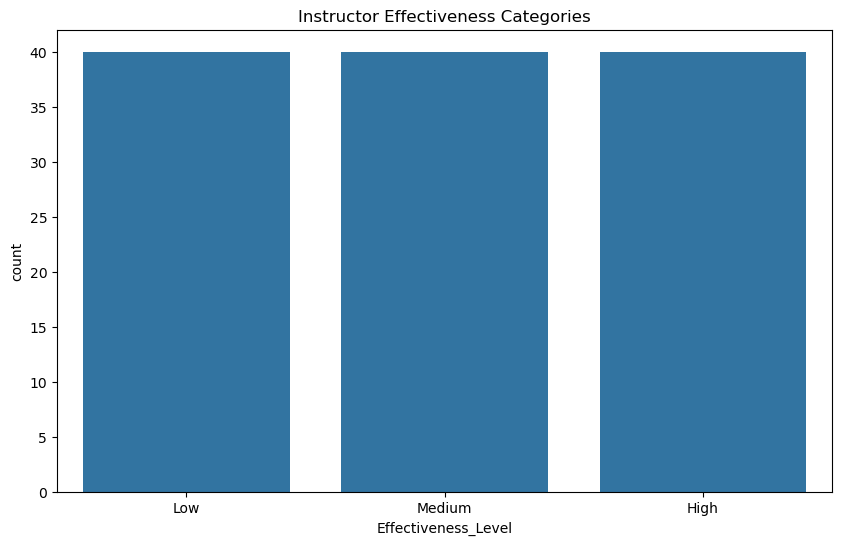

In [80]:
# Shows that each category contains roughly the same number of instructors, as expected from quantile-based binning.
plt.figure(figsize=(10,6))
sns.countplot(data=df_pivot, x='Effectiveness_Level')
plt.title("Instructor Effectiveness Categories")
plt.show()

In [74]:
df_pivot.sort_values('Instructor_Effectiveness', ascending=False).head(10)

,instructor_id,assignment_submission_rate_mean,avg_feedback_score_mean,avg_score_improvement_mean,avg_score_improvement_std,avg_watch_time_mean,completion_rate_count,completion_rate_mean,completion_rate_std,feedback_response_rate_mean,forum_activity_rate_mean,completion_consistency,improvement_consistency,Learning_Score,Engagement_Score,Feedback_Score,Instructor_Effectiveness,Effectiveness_Level
9,I_010,0.761195,0.901666,1.000000,0.415927,0.988380,0.250000,1.000000,0.398807,1.000000,1.000000,0.601193,0.584073,0.918527,0.916525,0.950833,0.922772,High
36,I_037,0.680908,0.879888,0.957464,0.531203,1.000000,0.333333,0.972539,0.193703,0.891623,0.926270,0.806297,0.468797,0.899511,0.869059,0.885755,0.888312,High
104,I_105,0.723155,0.851973,0.938656,0.204466,0.866915,0.375000,0.877423,0.292435,0.809097,0.883192,0.707565,0.795534,0.876742,0.824421,0.830535,0.854114,High
17,I_018,0.797773,0.993013,0.836194,0.280220,0.914670,0.291667,0.882437,0.518425,0.635681,0.991644,0.481575,0.719780,0.807588,0.901362,0.814347,0.836734,High
4,I_005,0.869081,0.516321,0.858811,0.482641,0.771647,0.500000,0.870836,0.491251,0.643863,0.954941,0.508749,0.517359,0.794470,0.865223,0.580092,0.783539,High
90,I_091,1.000000,0.833022,0.907882,0.632617,0.475935,0.041667,0.930404,0.412023,0.621957,0.637844,0.587977,0.367383,0.830850,0.704593,0.727489,0.777469,High
14,I_015,0.810731,0.867117,0.782623,0.647003,0.852388,0.416667,0.744908,0.420481,0.621322,0.730921,0.579519,0.352997,0.704264,0.798013,0.744220,0.738382,High
117,I_118,0.738620,1.000000,0.861807,0.598706,0.475285,0.500000,0.808683,0.597754,0.923062,0.607788,0.402246,0.401294,0.748550,0.607231,0.961531,0.738102,High
24,I_025,0.635146,0.705614,0.778370,0.679494,0.825942,0.500000,0.812005,0.648251,0.801186,0.768146,0.351749,0.320506,0.703376,0.743078,0.753400,0.722790,High
50,I_051,0.722322,0.821285,0.781915,0.650696,0.569164,0.791667,0.764878,0.589767,0.661932,0.782207,0.410233,0.349304,0.694671,0.691231,0.741609,0.700680,High


Summary: Instructor effectiveness was evaluated by aggregating batch-level metrics to the instructor level. A composite score was constructed using weighted dimensions representing learning outcomes (55%), learner engagement (30%), and learner feedback (15%). Learning outcomes were given the highest importance as they directly reflect the instructor's ability to facilitate student success, while engagement and feedback were treated as complementary indicators. To account for consistency across batches, standard deviation-based consistency scores were incorporated into the learning dimension. Finally, instructors were categorized into Low, Medium, and High effectiveness groups using quantile-based thresholds.

### ML Model Building:

I have decided to use Decision Tree Algorithm as our primary ML classification model to classify intructors into three levels:

- High
- Medium
- Low

Reason for Choosing DT Algorithm: The DT algorithm can work efficiently even with a small dataset such as df_pivot itself that just conatins 120 rows. It can handle non-linear relationships as well.

Other possible Classification Algorithms (and why they were not chosen):

- Naive Bayes: I did not choose this algorithm since it considers every feature independent of each other, which is not the case in our situation where every feature contributes some or the other to the output label decisions.

- Random Forest: It would have worked as well but it requires a larger dataset for it's training. Given our dataset is small, the RF algorithm would have underfitted.

- Logistic Regression: It would have not been much effective considering it mostly assumes a linear decision boundary. (It is worth considering though)


In [ ]:
# Defining the Features and the Target variable for the model. The features are all the columns except for 'Instructor_Effectiveness', 'Effectiveness_Level', and 'instructor_id'. The target variable is 'Effectiveness_Level'.
X = df_pivot.drop(columns=['Instructor_Effectiveness', 'Effectiveness_Level', 'instructor_id'])

y = df_pivot['Effectiveness_Level']

**Note:** I have dropped the "Instructor_Effectiveness" feature as well because the metric itself was created using our definition of instructor effectiveness of the form:
  - 0.55 * L + 0.3 * E + 0.15 F 

; and maps directly to the categories in effectiveness level.

The model may ignore other features and simply learn a linear relationship between instructor effectiveness and effectiveness level. This may cause overfitting and consequently, not generalise well on unseen data.

In [81]:
# Splitting the dataset into training and testing sets. 80% of the data will be used for training the model, and 20% will be used for testing its performance.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Stratify=y since we have three classes (Low, Medium, High) and we want to maintain the same proportion of each class in both training and testing datasets. 

In [ ]:
# Model Training: Using a Decision Tree Classifier to predict the effectiveness level of instructors based on their performance metrics.
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
# Maximum tree depth of 5 was chosen to reduce overfitting while maintaining sufficient model complexity to capture relationships between instructor performance metrics and effectiveness categories.
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
#Predictions based on X_test values as the unseen input to the model.
y_pred = dt.predict(X_test)

In [ ]:
# Evaluating the model's performance using accuracy score, and classification report to understand how well the model predicts instructor effectiveness levels.
from sklearn.metrics import accuracy_score,classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.875

Classification Report:

              precision    recall  f1-score   support

        High       0.88      0.88      0.88         8
         Low       0.89      1.00      0.94         8
      Medium       0.86      0.75      0.80         8

    accuracy                           0.88        24
   macro avg       0.87      0.88      0.87        24
weighted avg       0.87      0.88      0.87        24



### Conclusion
- An Accuracy Score of 0.875 or 87.5 % is not bad considering a lot of necessary assumptions and adjustments were made.

- The model demonstrates equally strong f1-scores (that inherently considers precison and recall- i.e. it considerate of how many true positives (actually correct labels) did the model get right and how many positively predicted labels were actually the correct labels) across all three categories. The f1-score remian > 80 % across all the labels, suggesting an overall good model performance.

- I tried the model with max_depth= 3, 4, 6 as well.

- For max_depth < 4: I observed that the accuracy was 100 %, probably overfitting (The reasons for which could not make out.)

- For max_depth > 5: The accuracy remained 87.5 %, suggesting that the value 5 is a suitable threshold for the model to work efficiently. Ideally, as the max_depth values increase, the model should Increase its accuracy score until it overfits but that wasn't the case at least until max_depth=6. I did not move further with the values.

- Overall, an EdTech Organisation can use this model to predict whether an existing instructor is effective or not using the included features in the df_pivot dataset. They can replicate this dataset and add on to it, the required data monthly, quarterly or yearly and analyse results. They can reward high achieving instructors, while encouraging them to continue their performance consistently and stay affiliated to their organisation. And the low performing instructors may be instructed to improve their overall performance overtime within ceratin period with the help of other instructors and improvement methodologies.

- While recruiting new instructors, organisations can analyse the candidates' previous data to deem them suitable or not, along with interviews and assessments. This analysis shall only provide supplementary support to hiring decisions as they do not represent the fix skills of an instructor.

- Following above procedures will help the EdTech organisation retain students, improve their performance and attract new students to opt for their courses.

### Mandatory Analysis Questions:

- Which features most influenced instructor effectiveness, and why?

  - If we consider the physical model I defined for Instructor effectiveness: 0.55L + 0.30E + 0.15F; I have provided a greater weightage to Learner Outcome metrics and Engagement Metrics than Feedback metrics because I beilieve they contribute significantly in evaluating how efficient an instructor is. Feedback metrics provide a supplementary support in this evaluation as they are vulnearble to several factors as discussed earlier. 

  - Rgarding the Decision Tree Model, it should roughly predict the labels according to the instructor effectiveness score function that defined (in the first half of the answer). Properties of defining the way in the model would predict the labels, is propagated through the "Effectiveness_Labels" which in turn were generated according to our defined function. Therefore, if the model generalises well (and it did to lot extent, as is evident from the above classification report), the model may encapsulate the process defined by the score formula, inherently.

- Which variables could be misleading or confounded?

  - I identified a major variable: "avg_quiz_score", that I believe could have caused ambiguity and incosistency in predicting accurate labels. The average quiz score, as explained earlier, may not be a proper indicator of an instructor if the avg quiz scores remain consistent no matter who the instructor is. On the other hand, avg_improvement_score can actually denote the instructors' effectiveness and the reason it being retained. Though it is worth observing on how the model would have performed if we included the avg_quiz_score metric/feature. 

  - I have also provided less weightage to feedback metrics because they are highly vulnerable to bias and other factors, as discussed before.

- How could this model fail in real-world usage?

  - The model does *not directly* take into consideration- learner's learning abilities/capabilities, their willingness to learn a course (they could be consistent or inconsistent, they could have opted the courses due to peer pressure, family pressure or initial, short-lived interest). These characteristics are learner specific and may not directly indicate an instructor's effectiveness. However, they certainly can be reflected in data relating to avg_watch_time, assignment_submission_rate, feedback scores, etc.

  - Therefore, this model could fail in a real-world scenearios where there is not much variability in interests of learning (high or low interests) and engaging in courses within batches of students or other similar reasons. Though these are ideally context-specific and rare to happen scenarios, we can not neglect these cases as variations of such cases might exist.

- What additional data would you want to improve this analysis?

  - If I were given a choice to include a data field to improve the model, I would have included the features mentioned in the third answer of this cell, i.e. Willingness to learn/interest (Categorical- High, medium, Low), and Learner's capabilities (Numerical- Some kind of score supported by (say) IQ, etc.) - however, the latter feature woudl only serve as static, limited-amount-of-time reliability indicator and it would have to be updated regularly.

  - I believe above indicators would help in defining learners' perspective of conduct and it would help in fine- tuning the model, a lot. The data could be acquired monthly or quarterly through surveys and feedback forms, along with feedback scores and more.

- Should this model be used for instructor performance evaluation? Why or why not?

  - As mentioned earlier (just the cell before this), this model should only be used to assess an instructor's effectiveness temporarily for instructor performance evaluation, as a supplementary support and for a point of time. On-ground assessments and regualr checks are always encouraged rather than solely depending on this model. Not to mention no model has 100 % accuracy and it certainly can not define an instructors' teaching efforts based on just certain metrics.